In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv(r"C:\Users\ADITYA GUPTA\Downloads\Data\genz_social_media_usage_1M.csv")
df.head(5)

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


In [49]:
df.shape

(1000000, 12)

In [50]:
df.isnull().sum()

age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64

In [51]:
df.dtypes

age                           int64
gender                          str
country                         str
daily_usage_hours           float64
primary_platform                str
num_platforms_used            int64
purpose                         str
avg_session_minutes         float64
night_usage                   int64
mental_health_score         float64
addiction_level                 str
screen_time_before_sleep    float64
dtype: object

In [52]:
df.describe()

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,19.994629,3.514998,2.999469,25.088819,0.599958,7.170671,40.120754
std,4.322119,1.468771,1.414598,9.794249,0.489907,1.503885,19.569847
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.493985,2.000000,18.257267,0.000000,6.147371,26.459592
50%,20.000000,3.503302,3.000000,25.002480,1.000000,7.198098,39.977162
75%,24.000000,4.513016,4.000000,31.759257,1.000000,8.243818,53.424345
max,27.000000,10.000000,5.000000,80.262224,1.000000,10.000000,137.998719


# Visualization

In [53]:
df.columns

Index(['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform',
       'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage',
       'mental_health_score', 'addiction_level', 'screen_time_before_sleep'],
      dtype='str')

In [54]:
df[['country']].value_counts()

country  
India        350321
USA          199740
Canada       100384
UK           100343
Germany       99896
Brazil        99532
Australia     49784
Name: count, dtype: int64

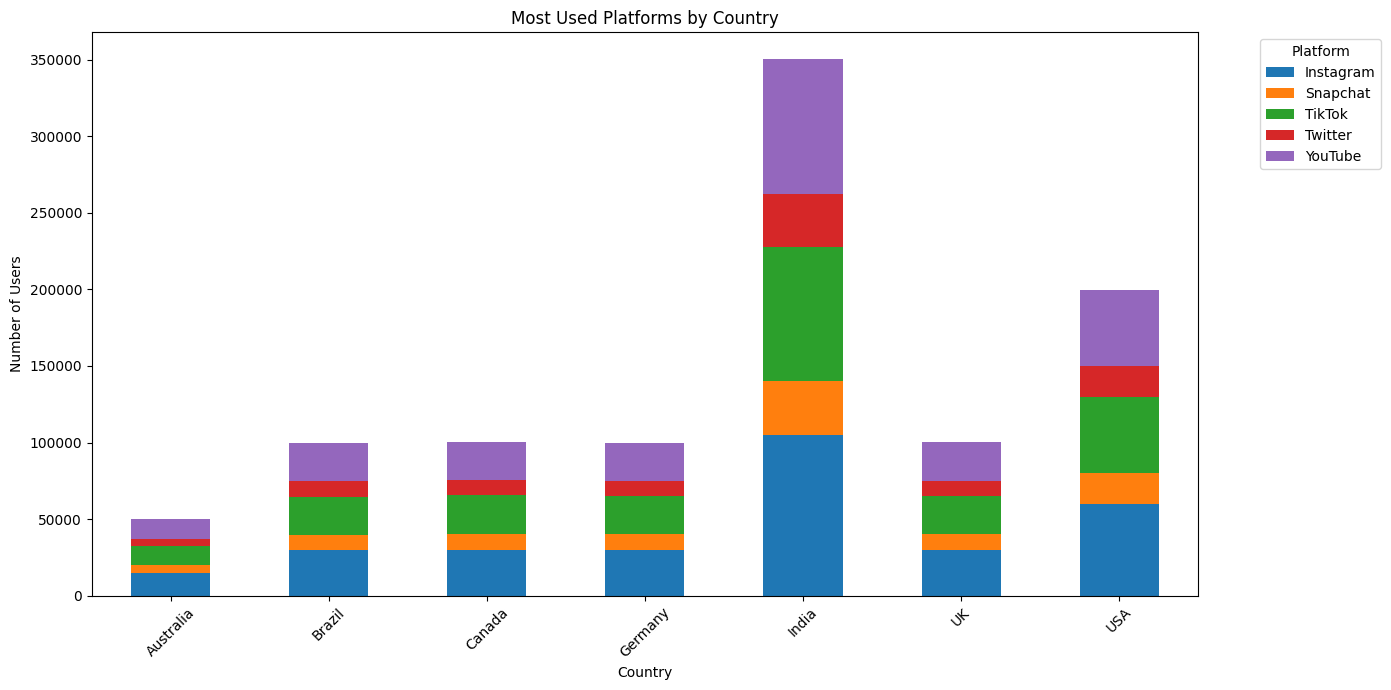

In [55]:
# First, we create a cross-tabulation to count each platform usage per country
platform_counts = pd.crosstab(df['country'], df['primary_platform'])

# Now we plot a stacked bar chart
platform_counts.plot(kind='bar', stacked=True, figsize=(14, 7))

plt.title('Most Used Platforms by Country')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [56]:
df[['purpose']].isnull().sum()

purpose    0
dtype: int64

       country primary_platform age_group        age
0    Australia        Instagram     13-18  15.011042
1    Australia        Instagram     19-25  21.023820
2    Australia        Instagram     26-35  26.012309
3    Australia         Snapchat     13-18  14.945015
4    Australia         Snapchat     19-25  20.983516
..         ...              ...       ...        ...
100        USA          Twitter     19-25  20.995532
101        USA          Twitter     26-35  26.000509
102        USA          YouTube     13-18  15.005140
103        USA          YouTube     19-25  20.996235
104        USA          YouTube     26-35  25.995352

[105 rows x 4 columns]


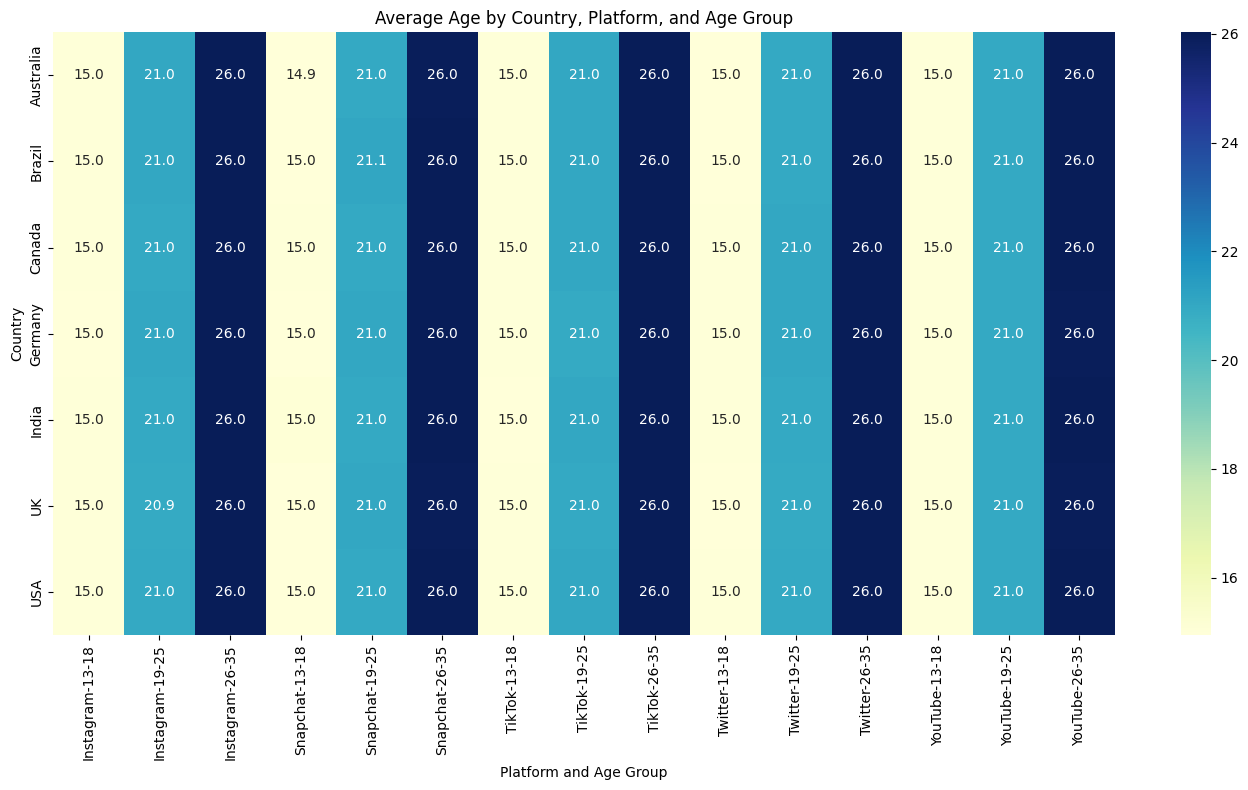

In [57]:
# Define age bins and labels
age_bins = [13, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['13-18', '19-25', '26-35', '36-45', '46-55', '56-65', '66+']

# Create a new column for age group
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Group by country, platform, and age group, then calculate the average age
grouped = df.groupby(['country', 'primary_platform', 'age_group'])['age'].mean().reset_index()

print(grouped)

# If you want to visualize it, you could use a pivot table and a heatmap
pivot = grouped.pivot_table(index='country', columns=['primary_platform', 'age_group'], values='age')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt=".1f")

plt.title('Average Age by Country, Platform, and Age Group')
plt.xlabel('Platform and Age Group')
plt.ylabel('Country')

plt.tight_layout()
plt.show()